In [1]:
# import libraries
import numpy as np
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [2]:
def categorize_diffusers(diffuser_coordinates, fg_coordinates, k, max_distance=5):
    """"Returns arrays containing the types and chain indices of the k closest FGs for each diffuser.

    Args:
        diffuser_coordinates (np.array): a coordinates array of shape [n_diffusers, 3]
        fg_coordinates (Dictionary(string : np.array)): a coordinates dictionary of shape {fg_type : [n_chains, n_beads, 3]}
        k (int): Number of closest FGs to find for each diffuser
        
    Returns:
        np.array: Array of shape [n_diffusers, k] containing strings in format "<fg_type>_<chain_i>"
        or "cyt"/"nuc" if no FG is within max_distance.
    """
    n_diffusers = diffuser_coordinates.shape[0]
    # Initialize results array
    result = np.full((n_diffusers, k), "cyt", dtype='U20')
    result[diffuser_coordinates[:,2] < 0, :] = "nuc"
    
    # Pre-calculate total number of chains
    total_chains = sum(coords.shape[0] for coords in fg_coordinates.values())
    
    # Pre-allocate arrays for all chains
    all_min_distances = np.zeros((n_diffusers, total_chains))
    all_formatted_strings = np.empty(total_chains, dtype='U20')
    
    # Calculate minimum distances for all chains at once
    current_idx = 0
    for fg_type, coords in fg_coordinates.items():
        n_chains = coords.shape[0]
        
        # Generate formatted strings for this FG type
        chain_strings = np.array([f"{fg_type}_{i:02d}" for i in range(n_chains)])
        all_formatted_strings[current_idx:current_idx + n_chains] = chain_strings
        
        # Reshape arrays for broadcasting
        chains_reshaped = coords.reshape(n_chains, -1, 3)  # [n_chains, n_beads, 3]
        diffusers_expanded = diffuser_coordinates[:, np.newaxis, np.newaxis, :]  # [n_diffusers, 1, 1, 3]
        
        # Calculate distances to all beads for all chains at once
        distances = np.linalg.norm(chains_reshaped[np.newaxis, :, :, :] - diffusers_expanded, axis=3)
        
        # Find minimum distance per chain
        all_min_distances[:, current_idx:current_idx + n_chains] = np.min(distances, axis=2)
        
        current_idx += n_chains
    
    # Process each diffuser using vectorized operations
    for i in range(n_diffusers):
        # Find valid distances within max_distance
        valid_mask = all_min_distances[i] <= max_distance
        
        if np.any(valid_mask):
            # Get valid distances and their indices
            valid_distances = all_min_distances[i][valid_mask]
            valid_strings = all_formatted_strings[valid_mask]
            
            # Get indices of k smallest distances
            k_smallest_indices = np.argsort(valid_distances)[:k]
            result[i, :len(k_smallest_indices)] = valid_strings[k_smallest_indices]
    
    return result


def categorize_diffusers_over_time(diffuser_trajectories, fg_trajectories, k, step=1):
    n_diffusers = diffuser_trajectories.shape[0]
    n_t = diffuser_trajectories.shape[2]
    n_t2 = fg_trajectories["Nsp1"].shape[3]
    if n_t != n_t2:
        raise Exception("Times not matching")
    n_columns = len(range(0, n_t, step))
    categorized_trajectories = np.zeros(shape=(n_diffusers, k, n_columns), dtype='U20')
    for t in range(0, n_t, step):
        cur_diffuser_trajectories = diffuser_trajectories[:, :, t]
        cur_fg_trajectories = {fg_type : fg_trajectories[:, :, :, t] for (fg_type, fg_trajectories) in fg_trajectories.items()}
        categorized_trajectories[:,:,int(t / step)] = categorize_diffusers(cur_diffuser_trajectories, cur_fg_trajectories, k)
    return categorized_trajectories

def infinitesimal_generator(P, dt=1.0):
    """
    Estimate the infinitesimal generator matrix Q from transition matrix P
    Implementation similar to: https://transitionmatrix.readthedocs.io/en/latest/_modules/transitionMatrix/model.html#TransitionMatrix.generator
    Units of Q are rate, i.e. 1/time. 
    expm(Q * dt) will result in P.
    
    Examples:
    If the units of P are transition probablities per 100ns,
    then the units of Q will be the transition rate 1 / (100ns * dt).
    
    
    Parameters:
    P : numpy.ndarray
        Transition matrix
    dt : float, optional
        The time scale parameter. 
    
    Returns:
    numpy.ndarray
        Infinitesimal generator matrix Q. 
    """
    return sp.linalg.logm(P) / dt

def normalize_rows(counts_matrix):
    transition_matrix = np.zeros_like(counts_matrix)
    n_states = counts_matrix.shape[0]
    for i in range(n_states):
        row_sum = np.sum(counts_matrix[i, :])
        if row_sum == 0:
            print(f"Row sum is 0, setting row {i} to 0    :( ")
            transition_matrix[i, :] = 0
            continue
        transition_matrix[i, :] = counts_matrix[i, :] / row_sum
    return transition_matrix

def generate_counts_matrix(data):
        # Get unique states
    fg_types = ['Nup2', 'Nsp1', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
    n_chains_per_fg = [16, 48, 16, 16, 16, 32, 32, 16, 8, 16]
    states = []
    for i, fg_type in enumerate(fg_types):
        for j in range(n_chains_per_fg[i]):
            states.append(f"{fg_type}_{j:02d}")
    states = sorted(states)
    states.append("nuc")
    states.append("cyt")
    n_states = len(states)
    
    # Create state to index mapping
    state_to_idx = {state: idx for idx, state in enumerate(states)}
    
    # Initialize transition counts
    counts = defaultdict(lambda: defaultdict(int))
    
    # Count transitions
    for sequence in data:
        for t in range(len(sequence) - 1):
            current_state = sequence[t]
            next_state = sequence[t + 1]
            counts[current_state][next_state] += 1
    return counts, states

def generate_transition_matrix(data, init_1 = False):
    """
    Generate a transition matrix from an array of categorical time series.
    
    Parameters:
    -----------
    data : array-like
        Array of shape [n_diffusers, t] containing categorical data (strings)
        
    Returns:
    --------
    transition_matrix : numpy.ndarray
        Matrix of transition probabilities
    states : list
        List of unique states (categories)
    """
    counts, states = generate_counts_matrix(data)
    n_states = len(states)
    
    # Create transition matrix
    if init_1: transition_matrix = np.ones((n_states, n_states))
    else: transition_matrix = np.zeros((n_states, n_states))
    
    # Fill transition matrix with probabilities
    for i, state_i in enumerate(states):
        for j, state_j in enumerate(states):
            transition_matrix[i, j] += counts[state_i][state_j]
    transition_matrix = normalize_rows(transition_matrix)
    
    return transition_matrix, states


def reorder_transition_matrix(transition_matrix, old_order, new_order):
    """
    Reorders a transition matrix according to a new specified order of states.
    """ 
    # Input validation
    if set(old_order) != set(new_order):
        raise ValueError("Old and new order must contain the same elements")
    
    if len(old_order) != len(new_order):
        raise ValueError("Old and new order must have the same length")
        
    if transition_matrix.shape != (len(old_order), len(old_order)):
        raise ValueError("Transition matrix dimensions must match the length of state lists")
    
    # Create mapping from old positions to new positions
    old_to_new = {state: new_order.index(state) for state in old_order}
    
    # Create the reordered matrix
    n = len(old_order)
    reordered_matrix = np.zeros((n, n))
    
    # Fill in the reordered matrix
    for i, old_from_state in enumerate(old_order):
        for j, old_to_state in enumerate(old_order):
            new_i = old_to_new[old_from_state]
            new_j = old_to_new[old_to_state]
            reordered_matrix[new_i, new_j] = transition_matrix[i, j]
            
    return reordered_matrix

In [12]:
def visualize_heatmap(data, labels=[], label_sizes=[], cbar_label=r'$Log_{10} (Pr[i \to j])$', title="", suptitle="",  first_and_last_factor=1):
    # Expand first and last rows
    first_row_repeated = np.tile(data[0, :], (first_and_last_factor-1, 1))
    data = np.append(first_row_repeated, data, axis=0)
    first_col_repeated = np.tile(data[:, 0], (first_and_last_factor-1, 1))
    data = np.append(first_col_repeated.T, data, axis=1)
    last_row_repeated = np.tile(data[-1, :], (first_and_last_factor-1, 1))
    data = np.append(data, last_row_repeated, axis=0)
    last_col_repeated = np.tile(data[:, -1], (first_and_last_factor-1, 1))
    data = np.append(data, last_col_repeated.T, axis=1)

    
    
    
    # Create the heatmap
    plt.imshow(data, cmap='jet', interpolation='nearest')
    
    # Add colorbar
    cbar = plt.colorbar()
    cbar.set_label(cbar_label)
    
    # Calculate tick positions (center of each group)
    tick_positions = []
    current_pos = 0
    
    for size in label_sizes:
        tick_positions.append(current_pos + size / 2 - 0.5)
        current_pos += size
    
    # Set ticks and labels
    plt.xticks(tick_positions, labels, rotation="vertical")
    plt.yticks(tick_positions, labels)
    
    # Add gridlines at label boundaries
    if len(label_sizes) > 1:
        grid_lines = [sum(label_sizes[:i]) - 0.5 for i in range(1, len(label_sizes))]
        for pos in grid_lines:
            plt.axhline(y=pos, color='black', linestyle='-', linewidth=0.5)
            plt.axvline(x=pos, color='black', linestyle='-', linewidth=0.5)
    
    # Set title and axis labels
    plt.suptitle(suptitle, fontsize=12)
    plt.title(title, fontsize=10)
    plt.xlabel("To")
    plt.ylabel("From")
    
    
    # Show the plot
    plt.show()

def labels_and_sizes(states, first_and_last_factor=5):

    labels = []
    label_sizes = []
    prev_label = ""
    cur_size = first_and_last_factor
    for i in range(len(states)):
        cur_label = states[i]    
        if cur_label == "nuc":
            labels.append(cur_label)
            prev_label = cur_label
            continue
        if cur_label == "cyt":
            labels.append(cur_label)
            label_sizes.append(cur_size)
            label_sizes.append(first_and_last_factor)
            prev_label = cur_label
            break
        
        cur_label = cur_label[:-3]
        
        if cur_label == prev_label:
            cur_size += 1
            continue
        label_sizes.append(cur_size)
        cur_size = 1
        labels.append(cur_label)
        prev_label = cur_label
    
    return labels, label_sizes

In [4]:
#############
# Load data #
#############
arrays = []
for i in range(1,51):
    print(f"{i} ", end="")
    with open(f"data/singles/{i}/150-160.pickle", "rb") as f:
        diffuser_trajectories = pickle.load(f)
    with open(f"data/singles/{i}/150-160-fgs.pickle", "rb") as f:
        fg_trajectories = pickle.load(f)
    arrays.append(categorize_diffusers_over_time(diffuser_trajectories, fg_trajectories, 1, step=1))
all = np.concatenate(arrays, axis=0)

#######################################
# Generate and save transition matrix #
#######################################
tm, states = generate_transition_matrix(all[:,0,:], init_1=True)
with open("data/transition_matrices/interactions-150-160.pickle", "wb") as f:
    pickle.dump((tm, states), f)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 

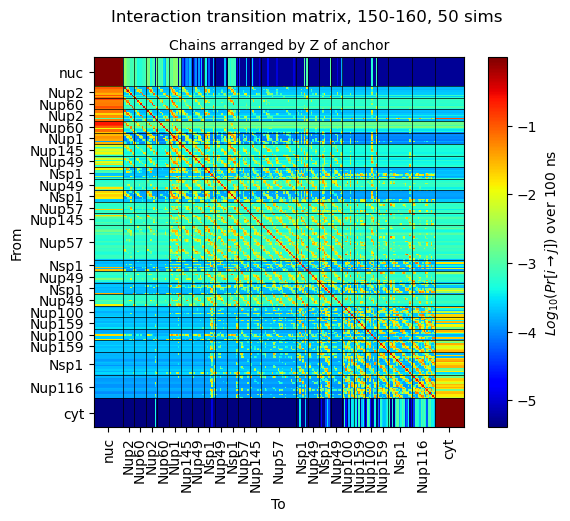

In [16]:
# Load and visualize transition matrix
from cProfile import label


with open("data/transition_matrices/interactions-150-160.pickle", "rb") as f:
    tm, states = pickle.load(f)


# sns.clustermap(np.log10(tm), metric='braycurtis')

# visualize_heatmap(np.log10(tm))





with open(f"data/anchor_coordinates.pickle", "rb") as f:
    anchor_coordinates = pickle.load(f)
    
# Sort anchor coordinates by Z
anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
tm = reorder_transition_matrix(tm, states, new_states)

first_and_last_factor = 20
labels, label_sizes = labels_and_sizes(new_states, first_and_last_factor=first_and_last_factor)
visualize_heatmap(np.log10(tm),
                  suptitle="Interaction transition matrix, 150-160, 50 sims",
                  title="Chains arranged by Z of anchor",
                  labels=labels,
                  label_sizes=label_sizes,
                  cbar_label=r'$Log_{10} (Pr[i \to j])$ over 100 ns',
                  first_and_last_factor=first_and_last_factor)